# Optimizing Gold Investment Decisions Gold Portfolio

# Libraries and Datasets

### i. Libraries

In [1]:
import os
import warnings 
import pandas as pd
import numpy as np
import pandoc
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.genmod import families
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.vector_ar.vecm import VECM
from statsmodels.tsa.statespace.dynamic_factor import DynamicFactor
from linearmodels.panel import RandomEffects, compare, PanelOLS
from statsmodels.stats.outliers_influence import variance_inflation_factor
from htmldocx import HtmlToDocx
warnings.filterwarnings("ignore") # suppress warnings
pd.set_option('display.max_rows', None) # set maximum rows
pd.set_option('display.max_columns', None) # set maximum columns
os.chdir('C:/Users/Joseph Otieno/Desktop/James Croyard/')

## ii. Datasets

In [2]:
# Gold price data
price_raw=pd.read_excel(r'Gold price.xlsx',sheet_name='Yearly_EoP',parse_dates=['Date'])
price_raw.head(10)

,Date,USD,EUR,JPY,GBP,CAD,CHF,INR,CNY,TRY,SAR,IDR,AED,THB,VND,EGP,KRW,RUB,ZAR,AUD
0,1978-12-29,226.00,137.06,NaN,110.70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1979-12-31,512.00,299.12,125630.27,230.63,611.81,835.57,4189.64,NaN,NaN,1749.03,324101.29,2055.87,10645.23,NaN,NaN,253615.89,NaN,434.07,474.31
2,1980-12-31,589.75,392.41,119823.10,246.65,703.65,1047.84,4620.33,NaN,NaN,1960.07,367506.77,2149.91,12026.69,NaN,NaN,389010.82,NaN,439.10,499.39
3,1981-12-31,397.50,327.48,87899.49,208.22,475.33,719.75,3625.14,NaN,NaN,1372.45,249492.07,1456.26,9089.58,NaN,NaN,280200.10,NaN,383.13,354.95
4,1982-12-31,456.90,429.90,105366.41,282.47,551.23,899.77,4320.02,NaN,0.08,1543.06,310012.88,1642.33,10239.95,NaN,NaN,335836.82,NaN,482.61,456.82
5,1983-12-30,382.40,432.00,88442.82,263.45,474.54,831.86,3995.04,NaN,0.11,1334.40,380175.33,1368.83,8699.72,NaN,NaN,303482.93,NaN,466.42,424.34
6,1984-12-31,308.30,402.45,77716.67,266.01,408.23,803.83,3825.85,NaN,0.14,1106.43,331867.44,1134.42,8219.40,NaN,NaN,255666.66,NaN,612.80,374.12
7,1985-12-31,326.80,347.51,65490.56,226.08,457.19,673.57,3920.61,1047.35,0.18,1193.58,366475.66,1196.70,8614.44,NaN,NaN,291095.45,NaN,843.91,479.59
8,1986-12-31,388.75,337.80,61832.14,262.23,540.01,630.19,5060.97,1430.87,0.28,1465.78,632246.06,1434.40,9953.79,NaN,NaN,333768.27,NaN,851.15,587.39
9,1987-12-31,484.10,351.76,58714.40,257.71,629.51,616.76,6116.85,1758.86,0.47,1820.34,776608.67,1781.52,11789.23,NaN,NaN,379396.72,NaN,934.28,669.55


In [3]:
## inflation rate
inflation_raw=pd.read_csv(r'Inflation rate.csv', skiprows=16,parse_dates=['date'])
inflation_raw.head(10)

,date,Inflation Rate (%),Annual Change,
0,1992-12-31,-10.6301,NaN,NaN
1,1993-12-31,1128.0000,1138.63,NaN
2,1994-12-31,1662.2159,534.22,NaN
3,1995-12-31,411.7596,-1250.46,NaN
4,1996-12-31,19.7948,-391.96,NaN
5,1997-12-31,3.6743,-16.12,NaN
6,1998-12-31,-0.7727,-4.45,NaN
7,1999-12-31,-8.5252,-7.75,NaN
8,2000-12-31,1.8050,10.33,NaN
9,2001-12-31,1.5472,-0.26,NaN


In [4]:
## interest rate
interest_raw=pd.read_excel(r'Interest_rates_Aze.xlsx',sheet_name='Table 3.1',skiprows=8)
interest_raw.head(10)

,Country code,Descriptor,INDICATOR,UNIT_MULT,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2005-01,2005-02,2005-03,2005-04,2005-05,2005-06,2005-07,2005-08,2005-09,2005-10,2005-11,2005-12,2006,2006-01,2006-02,2006-03,2006-04,2006-05,2006-06,2006-07,2006-08,2006-09,2006-10,2006-11,2006-12,2007,2007-01,2007-02,2007-03,2007-04,2007-05,2007-06,2007-07,2007-08,2007-09,2007-10,2007-11,2007-12,2008,2008-01,2008-02,2008-03,2008-04,2008-05,2008-06,2008-07,2008-08,2008-09,2008-10,2008-11,2008-12,2009,2009-01,2009-02,2009-03,2009-04,2009-05,2009-06,2009-07,2009-08,2009-09,2009-10,2009-11,2009-12,2010,2010-01,2010-02,2010-03,2010-04,2010-05,2010-06,2010-07,2010-08,2010-09,2010-10,2010-11,2010-12,2011,2011-01,2011-02,2011-03,2011-04,2011-05,2011-06,2011-07,2011-08,2011-09,2011-10,2011-11,2011-12,2012,2012-01,2012-02,2012-03,2012-04,2012-05,2012-06,2012-07,2012-08,2012-09,2012-10,2012-11,2012-12,2013-01,2013-02,2013-03,2013-04,2013-05,2013-06,2013-07,2013-08,2013-09,2013-10,2013-11,2013-12,2014-01,2014-02,2014-03,2014-04,2014-05,2014-06,2014-07,2014-08,2014-09,2014-10,2014-11,2014-12,2015-01,2015-02,2015-03,2015-04,2015-05,2015-06,2015-07,2015-08,2015-09,2015-10,2015-11,2015-12,2016-01,2016-02,2016-03,2016-04,2016-05,2016-06,2016-07,2016-08,2016-09,2016-10,2016-11,2016-12,2017-01,2017-02,2017-03,2017-04,2017-05,2017-06,2017-07,2017-08,2017-09,2017-10,2017-11,2017-12,2018-01,2018-02,2018-03,2018-04,2018-05,2018-06,2018-07,2018-08,2018-09,2018-10,2018-11,2018-12,2018-12.1,2019-01,2019-02,2019-03,2019-04,2019-05,2019-06,2019-07,2019-08,2019-09,2019-10,2019-11,2019-12,2020-01,2020-02,2020-03,2020-04,2020-05,2020-06,2020-07,2020-08,2020-09,2020-10,2020-11,2020-12,2021-01,2021-02,2021-03,2021-04,2021-05,2021-06,2021-07,2021-08,2021-09,2021-10,2021-11,2021-12,2022-01,2022-02,2022-03,2022-04,2022-05,2022-06,2022-07,2022-08,2022-09,2022-10,2022-11,2022-12,2023-01,2023-02,2023-03,2023-04,2023-05,2023-06,2023-07,2023-08,2023-09,2023-10,2023-11,2023-12,2024-01,Unnamed: 252,Unnamed: 253,Unnamed: 254,Unnamed: 255,Unnamed: 256,Unnamed: 257,Unnamed: 258,Unnamed: 259,Unnamed: 260,Unnamed: 261,Unnamed: 262,Unnamed: 263,Unnamed: 264,Unnamed: 265,Unnamed: 266,Unnamed: 267,Unnamed: 268,Unnamed: 269,Unnamed: 270,Unnamed: 271,Unnamed: 272,Unnamed: 273,Unnamed: 274,Unnamed: 275,Unnamed: 276,Unnamed: 277,Unnamed: 278,Unnamed: 279,Unnamed: 280,Unnamed: 281,Unnamed: 282,Unnamed: 283,Unnamed: 284,Unnamed: 285,Unnamed: 286,Unnamed: 287,Unnamed: 288,Unnamed: 289,Unnamed: 290,Unnamed: 291,Unnamed: 292,Unnamed: 293,Unnamed: 294,Unnamed: 295,Unnamed: 296,Unnamed: 297,Unnamed: 298,Unnamed: 299,Unnamed: 300,Unnamed: 301,Unnamed: 302,Unnamed: 303,Unnamed: 304,Unnamed: 305,Unnamed: 306,Unnamed: 307,Unnamed: 308,Unnamed: 309,Unnamed: 310,Unnamed: 311,Unnamed: 312,Unnamed: 313,Unnamed: 314,Unnamed: 315,Unnamed: 316,Unnamed: 317,Unnamed: 318,Unnamed: 319,Unnamed: 320,Unnamed: 321,Unnamed: 322,Unnamed: 323,Unnamed: 324,Unnamed: 325,Unnamed: 326,Unnamed: 327,Unnamed: 328,Unnamed: 329,Unnamed: 330,Unnamed: 331,Unnamed: 332,Unnamed: 333,Unnamed: 334,Unnamed: 335,Unnamed: 336,Unnamed: 337,Unnamed: 338,Unnamed: 339,Unnamed: 340,Unnamed: 341,Unnamed: 342,Unnamed: 343,Unnamed: 344,Unnamed: 345,Unnamed: 346,Unnamed: 347,Unnamed: 348,Unnamed: 349,Unnamed: 350,Unnamed: 351,Unnamed: 352,Unnamed: 353,Unnamed: 354,Unnamed: 355,Unnamed: 356,Unnamed: 357,Unnamed: 358,Unnamed: 359,Unnamed: 360,Unnamed: 361,Unnamed: 362,Unnamed: 363,Unnamed: 364,Unnamed: 365,Unnamed: 366,Unnamed: 367,Unnamed: 368,Unnamed: 369,Unnamed: 370,Unnamed: 371,Unnamed: 372,Unnamed: 373,Unnamed: 374,Unnamed: 375,Unnamed: 376,Unnamed: 377,Unnamed: 378,Unnamed: 379,Unnamed: 380,Unnamed: 381,Unnamed: 382,Unnamed: 383,Unnamed: 384,Unnamed: 385,Unnamed: 386,Unnamed: 387,Unnamed: 388,Unnamed: 389,Unnamed: 390,Unnamed: 391,Unnamed: 392,Unnamed: 393,Unnamed: 394,Unnamed: 395,Unnamed: 396,Unnamed: 397,Unnamed: 398,Unnamed: 399,Unnamed: 400,Unnamed: 401,Unnamed: 402,Unnamed: 403,Unnamed: 404,Unnamed: 405,Unnamed: 406,Unnamed:

In [5]:
## USD to Azerbaijan exchange rates
exchange_raw=pd.read_csv(r'USD_AZN exchange rate_ 1 usd.csv',parse_dates=['Date'])
exchange_raw.head(10)

,Date,Price,Open,High,Low,Vol.,Change %
0,2024-03-01,1.7,1.7,1.7,1.7,NaN,0.00%
1,2024-02-01,1.7,1.7,1.7,1.7,NaN,0.00%
2,2024-01-01,1.7,1.7,1.7,1.7,NaN,0.00%
3,2023-12-01,1.7,1.7,1.7,1.7,NaN,0.00%
4,2023-11-01,1.7,1.7,1.7,1.7,NaN,0.00%
5,2023-10-01,1.7,1.7,1.7,1.7,NaN,0.00%
6,2023-09-01,1.7,1.7,1.7,1.7,NaN,0.00%
7,2023-08-01,1.7,1.7,1.7,1.7,NaN,0.00%
8,2023-07-01,1.7,1.7,1.7,1.7,NaN,0.00%
9,2023-06-01,1.7,1.7,1.7,1.7,NaN,0.00%


# Data Preprocessing

## Dealing with gold prices extraction

In [6]:
# select required variables from the dataset
price=price_raw[['Date','USD']]
# rename USD to Gold prices
price=price.rename(columns={'USD':'Gold Prices ($)'})
price=price.loc[(price['Date']>='2012-01-01') & (price['Date']<='2022-12-31')]
price['Year']=price['Date'].dt.year.astype(int)
# view the final price dataset
price.head()

,Date,Gold Prices ($),Year
34,2012-12-31,1657.5,2012
35,2013-12-31,1204.5,2013
36,2014-12-31,1206.0,2014
37,2015-12-31,1060.0,2015
38,2016-12-30,1145.9,2016


In [7]:
price.tail()

,Date,Gold Prices ($),Year
40,2018-12-31,1279.00,2018
41,2019-12-31,1514.75,2019
42,2020-12-31,1887.60,2020
43,2021-12-31,1805.85,2021
44,2022-12-30,1813.75,2022


## Extraction of inflation rates

In [8]:
inflation=inflation_raw.loc[(inflation_raw['date']>='2012-01-01') & (inflation_raw['date']<='2022-12-31')]
#select required columns
inflation=inflation.iloc[:,[0,1]]
inflation.columns=['Date','Inflation Rate (%)'] # rename columns
inflation['Year']=inflation['Date'].dt.year.astype(int)
#view the dataset
inflation.head()

,Date,Inflation Rate (%),Year
20,2012-12-31,1.0662,2012
21,2013-12-31,2.4157,2013
22,2014-12-31,1.3734,2014
23,2015-12-31,4.0277,2015
24,2016-12-31,12.4434,2016


In [9]:
inflation.tail()

,Date,Inflation Rate (%),Year
26,2018-12-31,2.2685,2018
27,2019-12-31,2.6106,2019
28,2020-12-31,2.7598,2020
29,2021-12-31,6.6503,2021
30,2022-12-31,13.8523,2022


## Extraction of interest rates

In [10]:
# extract interest rates for Azerbaijan only
interest_df=interest_raw.iloc[1,4:248] # selecting only relevant columns and rows
# convert to dataframe
interest_df=pd.DataFrame(interest_df) # converting to datafrane
interest_df.reset_index(inplace=True) #reset column 
interest_df.columns=['Date','Interest Rate (%)'] # rename all columns
interest_df['Date']=interest_df['Date'].astype(str) # convert to string the date name
interest_df['Date']=interest_df['Date'].str.replace(r'\.1$', '')
interest_df=interest_df.loc[(interest_df['Date']>='2012-01') & (interest_df['Date']<='2022-12')]
interest_df['Date']=pd.to_datetime(interest_df['Date'],format='%Y-%m')
interest_df['Year']=interest_df['Date'].dt.year.astype(int)
interest_df['Interest Rate (%)']=pd.to_numeric(interest_df['Interest Rate (%)'], errors='coerce') # convert to numeric
# final interest dataset
interest = interest_df.groupby('Year')['Interest Rate (%)'].mean().reset_index() # find mean of the months in each year
interest.columns=['Year','Interest Rate (%)'] # rename all columns
interest.head() # view final interest dataset

,Year,Interest Rate (%)
0,2012,5.229167
1,2013,4.770833
2,2014,4.104167
3,2015,3.250000
4,2016,9.375000


In [11]:
interest.tail()

,Year,Interest Rate (%)
6,2018,10.923077
7,2019,8.458333
8,2020,7.166667
9,2021,6.555556
10,2022,7.791667


## Extraction of Exchange Rates

In [12]:
# select required variables from the dataset
exchange=exchange_raw[['Date','Price']]
# rename USD to Gold prices
exchange=exchange.rename(columns={'Price':'Exchange Rates (USD/AZN)'})
exchange=exchange.loc[(exchange['Date']>='2012-01-01') & (exchange['Date']<='2022-12-31')]
exchange['Year']=exchange['Date'].dt.year.astype(int)
exchange=exchange.sort_values(by='Date')
exchange = exchange.groupby('Year')['Exchange Rates (USD/AZN)'].mean().reset_index() # find mean of the months in each year
# view the final price dataset
exchange.head()

,Year,Exchange Rates (USD/AZN)
0,2012,0.784636
1,2013,0.783667
2,2014,0.784667
3,2015,1.067508
4,2016,1.606525


In [13]:
exchange.tail()

,Year,Exchange Rates (USD/AZN)
6,2018,1.701225
7,2019,1.702500
8,2020,1.703542
9,2021,1.704833
10,2022,1.705925


## Merging all the Datasets

In [14]:
price=price.iloc[:,[2,1]]
inflation=inflation.iloc[:,[2,1]]
df = pd.merge(pd.merge(pd.merge(price, inflation,on='Year',how='inner'), interest,on='Year',how='inner'), exchange,on='Year',how='inner')
# export final dataset to csv
df.to_csv("Final dataset.csv",index=False)
X=df.drop("Gold Prices ($)",axis=1)
y=df['Gold Prices ($)']
df

,Year,Gold Prices ($),Inflation Rate (%),Interest Rate (%),Exchange Rates (USD/AZN)
0,2012,1657.50,1.0662,5.229167,0.784636
1,2013,1204.50,2.4157,4.770833,0.783667
2,2014,1206.00,1.3734,4.104167,0.784667
3,2015,1060.00,4.0277,3.250000,1.067508
4,2016,1145.90,12.4434,9.375000,1.606525
5,2017,1291.00,12.9359,15.000000,1.723492
6,2018,1279.00,2.2685,10.923077,1.701225
7,2019,1514.75,2.6106,8.458333,1.702500
8,2020,1887.60,2.7598,7.166667,1.703542
9,2021,1805.85,6.6503,6.555556,1.704833


# Data Understanding

In [15]:
# data shape
df.shape

(11, 5)

In [16]:
# data structure
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 11 entries, 0 to 10
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Year                      11 non-null     int32  
 1   Gold Prices ($)           11 non-null     float64
 2   Inflation Rate (%)        11 non-null     float64
 3   Interest Rate (%)         11 non-null     float64
 4   Exchange Rates (USD/AZN)  11 non-null     float64
dtypes: float64(4), int32(1)
memory usage: 484.0 bytes


In [17]:
# missing values
df.isna().sum()

Year                        0
Gold Prices ($)             0
Inflation Rate (%)          0
Interest Rate (%)           0
Exchange Rates (USD/AZN)    0
dtype: int64

# Descriptive Statistics

In [18]:
df.columns=['Year','Gold Prices ($)','Inflation Rate (%)','Interest Rate (%)','Exchange Rates (USD/AZN)']
df.iloc[:, 1:].describe().T

,count,mean,std,min,25%,50%,75%,max
Gold Prices ($),11.0,1442.350000,302.646191,1060.000000,1205.250000,1291.000000,1731.675000,1887.600000
Inflation Rate (%),11.0,5.673073,4.989248,1.066200,2.342100,2.759800,9.546850,13.852300
Interest Rate (%),11.0,7.511315,3.401286,3.250000,5.000000,7.166667,8.916667,15.000000
Exchange Rates (USD/AZN),11.0,1.388047,0.430621,0.783667,0.926087,1.701225,1.704187,1.723492


# Correlation Analysis

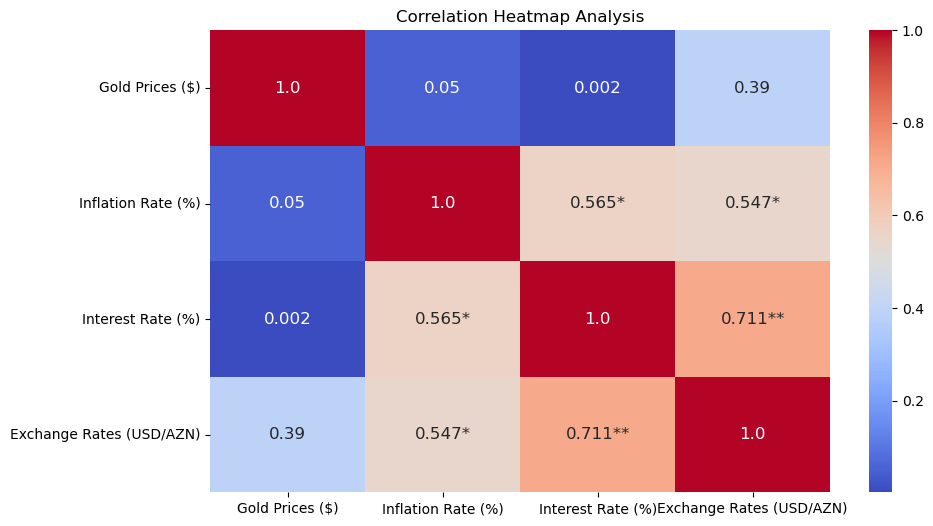

In [19]:
correlations = df.iloc[:, 1:].corr()
p_values = df.iloc[:, 1:].corr(method=lambda x, y: pearsonr(x, y)[1])

# Function to map p-values to stars
def map_pvalues_to_stars(p_values):
    stars = np.where(p_values < 0.01, '***',
                     np.where(p_values < 0.05, '**',
                              np.where(p_values < 0.1, '*',
                                       '')))
    return stars
# Map p-values to stars
stars = p_values.applymap(lambda x: map_pvalues_to_stars(x))
# Combine correlations with stars
correlations_with_stars = correlations.round(3).astype(str) + stars
# Create a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlations.round(3), annot=correlations_with_stars, fmt='', cmap='coolwarm', annot_kws={"size": 12})
plt.title('Correlation Heatmap Analysis')
plt.show()

# Regression Analysis

## Multiple Linear Regression Analysis

In [20]:
form1='Q("Gold Prices ($)") ~Q("Inflation Rate (%)") +Q("Interest Rate (%)") + Q("Exchange Rates (USD/AZN)")'
m1=smf.ols(formula=form1,data=df).fit()
print(m1.summary())

                             OLS Regression Results                             
Dep. Variable:     Q("Gold Prices ($)")   R-squared:                       0.313
Model:                              OLS   Adj. R-squared:                  0.018
Method:                   Least Squares   F-statistic:                     1.061
Date:                  Thu, 04 Apr 2024   Prob (F-statistic):              0.424
Time:                          22:50:18   Log-Likelihood:                -75.861
No. Observations:                    11   AIC:                             159.7
Df Residuals:                         7   BIC:                             161.3
Df Model:                             3                                         
Covariance Type:              nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------

## Robust Linear Models (RLM)

In [21]:
m2=smf.rlm(formula=form1,data=df).fit()
print(m2.summary())

                     Robust linear Model Regression Results                     
Dep. Variable:     Q("Gold Prices ($)")   No. Observations:                   11
Model:                              RLM   Df Residuals:                        7
Method:                            IRLS   Df Model:                            3
Norm:                            HuberT                                         
Scale Est.:                         mad                                         
Cov Type:                            H1                                         
Date:                  Thu, 04 Apr 2024                                         
Time:                          22:50:19                                         
No. Iterations:                       8                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------

## Generalized Linear Models (GLM)

In [22]:
m3=smf.glm(formula=form1,data=df).fit()
print(m3.summary())

                  Generalized Linear Model Regression Results                   
Dep. Variable:     Q("Gold Prices ($)")   No. Observations:                   11
Model:                              GLM   Df Residuals:                        7
Model Family:                  Gaussian   Df Model:                            3
Link Function:                 Identity   Scale:                          89943.
Method:                            IRLS   Log-Likelihood:                -75.861
Date:                  Thu, 04 Apr 2024   Deviance:                   6.2960e+05
Time:                          22:50:22   Pearson chi2:                 6.30e+05
No. Iterations:                       3   Pseudo R-squ. (CS):             0.3146
Covariance Type:              nonrobust                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------

## Generalized Estimation Equations (GEE)

In [23]:
m4=smf.gee(formula=form1,groups='Year',data=df).fit()
print(m4.summary())

                               GEE Regression Results                              
Dep. Variable:        Q("Gold Prices ($)")   No. Observations:                   11
Model:                                 GEE   No. clusters:                       11
Method:                        Generalized   Min. cluster size:                   1
                      Estimating Equations   Max. cluster size:                   1
Family:                           Gaussian   Mean cluster size:                 1.0
Dependence structure:         Independence   Num. iterations:                     1
Date:                     Thu, 04 Apr 2024   Scale:                       89943.126
Covariance type:                    robust   Time:                         22:50:23
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                      1028.8043    280.

## Mixed Effects Models (MixedLM)

In [24]:
m5=smf.mixedlm(formula=form1,groups='Year',data=df).fit()
print(m5.summary())

                    Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     Q("Gold Prices ($)")
No. Observations:     11          Method:                 REML                
No. Groups:           11          Scale:                  44971.5631          
Min. group size:      1           Log-Likelihood:         -55.9213            
Max. group size:      1           Converged:              Yes                 
Mean group size:      1.0                                                     
------------------------------------------------------------------------------
                                Coef.   Std.Err.   z    P>|z|  [0.025  0.975] 
------------------------------------------------------------------------------
Intercept                      1028.804  323.432  3.181 0.001 394.889 1662.720
Q("Inflation Rate (%)")          -6.200   19.521 -0.318 0.751 -44.460   32.060
Q("Interest Rate (%)")          -46.349   16.431 -2.821 0.005 -78.553  -1

# Timeseries Analysis

## Timeseries plot

In [25]:
df_series=df
df_series['Year']=pd.to_datetime(df_series['Year'],format='%Y')
df_series.set_index('Year',inplace=True)
df_series.index=df_series.index+pd.DateOffset(years=1)-pd.DateOffset(days=1)
df_series=pd.DataFrame(df_series)
df_series.head()

,Gold Prices ($),Inflation Rate (%),Interest Rate (%),Exchange Rates (USD/AZN)
Year,,,,
2012-12-31,1657.5,1.0662,5.229167,0.784636
2013-12-31,1204.5,2.4157,4.770833,0.783667
2014-12-31,1206.0,1.3734,4.104167,0.784667
2015-12-31,1060.0,4.0277,3.250000,1.067508
2016-12-31,1145.9,12.4434,9.375000,1.606525


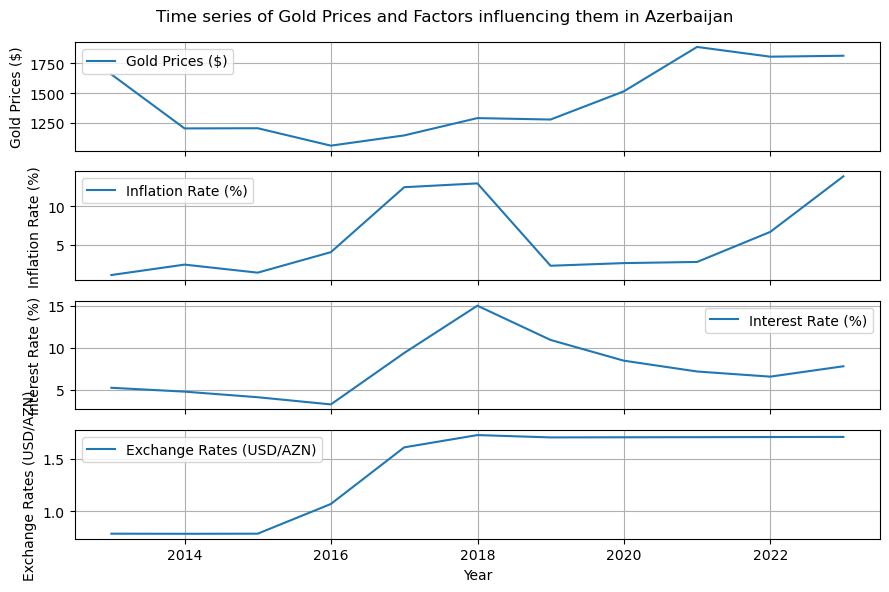

In [26]:
fig,axs=plt.subplots(4,1,figsize=(9,6),sharex=True)
for i, column in enumerate(df_series.columns):
    axs[i].plot(df_series.index,df_series[column],label=column)
    axs[i].set_ylabel(column)
    axs[i].grid(True)
    axs[i].legend()
plt.suptitle("Time series of Gold Prices and Factors influencing them in Azerbaijan")
plt.xlabel("Year")
plt.tight_layout()
plt.show()

## Stationarity Test

In [27]:
for column in df_series.columns:
    result=adfuller(df_series[column])
    print(f'ADF Test Results for {column}:')
    print('ADF Statistics',result[0])
    print('p-value:', result[1])
    print('Critical values:')
    for key, value in result[4].items():
        print(f'{key}: {value}')
        print('\n')

ADF Test Results for Gold Prices ($):
ADF Statistics -0.888868762944634
p-value: 0.7916159884590881
Critical values:
1%: -4.331573


5%: -3.23295


10%: -2.7487


ADF Test Results for Inflation Rate (%):
ADF Statistics -4.136413374851809
p-value: 0.0008426665379219403
Critical values:
1%: -4.9386902332361515


5%: -3.477582857142857


10%: -2.8438679591836733


ADF Test Results for Interest Rate (%):
ADF Statistics -4.734818439428539
p-value: 7.235197304206133e-05
Critical values:
1%: -4.9386902332361515


5%: -3.477582857142857


10%: -2.8438679591836733


ADF Test Results for Exchange Rates (USD/AZN):
ADF Statistics -179.4016105756245
p-value: 0.0
Critical values:
1%: -4.9386902332361515


5%: -3.477582857142857


10%: -2.8438679591836733




## Vecto-Autoregressive Regression

In [28]:
# Fit the VAR model
var = VAR(df_series).fit()
# Forecast future values
forecast = var.forecast(var.endog, steps=5)
print(var.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 04, Apr, 2024
Time:                     22:50:31
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                    8.06439
Nobs:                     10.0000    HQIC:                   6.79535
Log likelihood:          -74.0536    FPE:                    2575.16
AIC:                      7.45922    Det(Omega_mle):         508.674
--------------------------------------------------------------------
Results for equation Gold Prices ($)
                                 coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------------------------
const                             268.247489       211.335850            1.269           0.204
L1.Gold Prices ($)                  0.346916         0.162901            2.130           

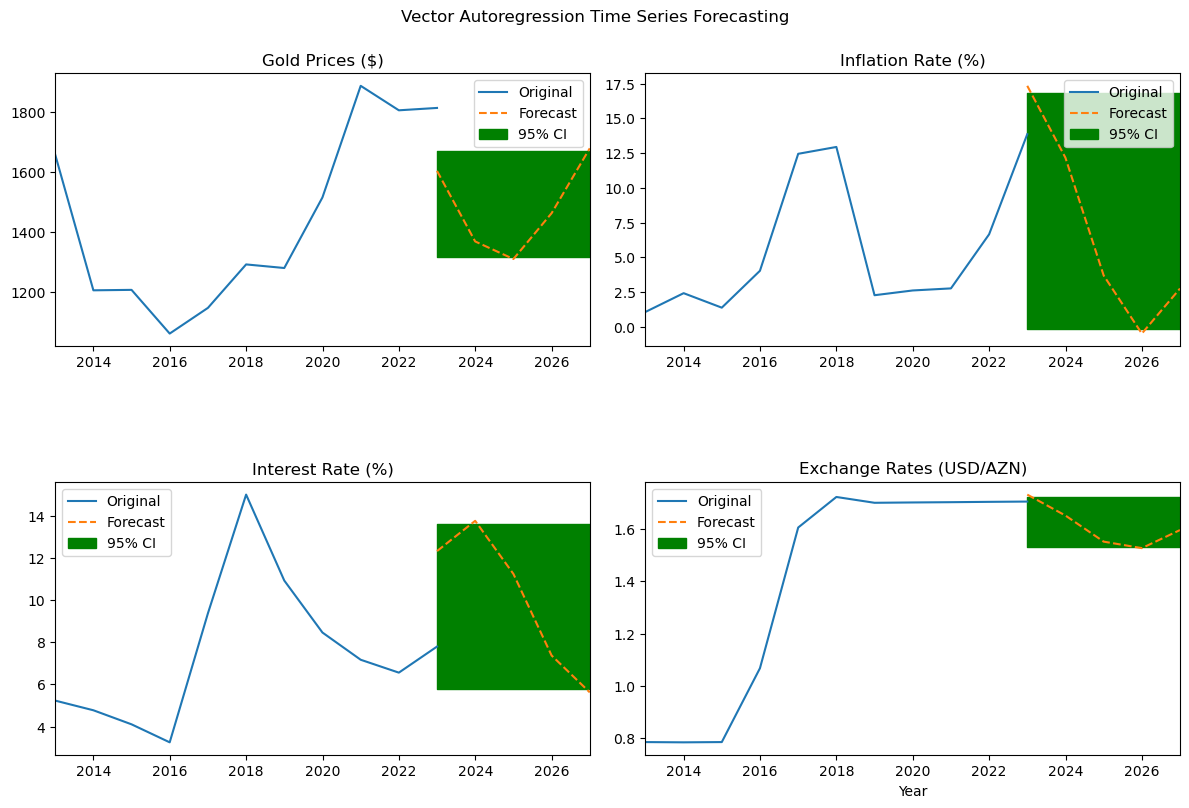

In [29]:
# Convert forecast to DataFrame
var_df = pd.DataFrame(forecast, index=pd.date_range(start=df_series.index[-1], periods=5, freq='Y'), columns=df_series.columns)
# Plotting
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
for i, col in enumerate(df_series.columns):
    ax = axes[i //2, i % 2]
    ax.plot(df_series.index, df_series[col], label='Original')
    ax.plot(var_df.index, var_df[col], label='Forecast', linestyle='--')
    ax.fill_between(var_df.index,var_df[col].quantile(0.025),var_df[col].quantile(0.975),color='green',label='95% CI')
    ax.set_title(col)
    ax.legend()
    ax.set_xlim(left=df_series.index[0],
               right=var_df.index[-1])
plt.tight_layout()
plt.suptitle("Vector Autoregression Time Series Forecasting")
plt.subplots_adjust(top=.9,hspace=.5)
plt.xlabel("Year")
plt.show()

In [30]:
var_df

,Gold Prices ($),Inflation Rate (%),Interest Rate (%),Exchange Rates (USD/AZN)
2022-12-31,1603.427198,17.334049,12.320466,1.732604
2023-12-31,1367.754614,12.164912,13.755834,1.652450
2024-12-31,1309.059697,3.688635,11.235651,1.552427
2025-12-31,1462.052725,-0.490393,7.369423,1.527571
2026-12-31,1678.818217,2.750481,5.621058,1.596815


## Vector Error Correction Models (VECM)

In [31]:
# Fit the VECM model
vecm = VECM(df_series).fit()
# Forecast future values
vecm_forecast = vecm.predict(steps=5)
print(vecm.summary())

 Det. terms outside the coint. relation & lagged endog. parameters for equation Gold Prices ($)
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
L1.Gold Prices ($)              0.7110      0.273      2.601      0.009       0.175       1.247
L1.Inflation Rate (%)          47.1261     23.541      2.002      0.045       0.987      93.266
L1.Interest Rate (%)         -265.2942     93.230     -2.846      0.004    -448.022     -82.567
L1.Exchange Rates (USD/AZN)  1169.1719    299.555      3.903      0.000     582.055    1756.289
Det. terms outside the coint. relation & lagged endog. parameters for equation Inflation Rate (%)
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
L1.Gold Prices ($)             -0.0086

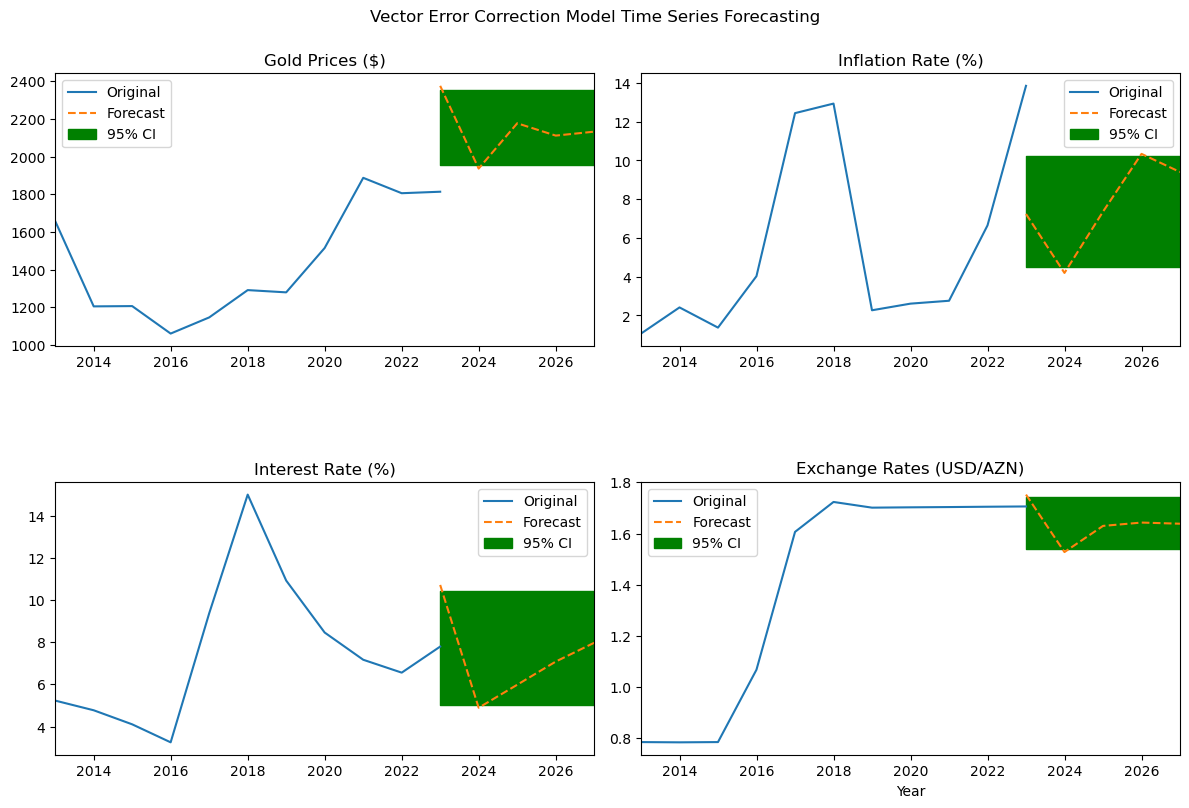

In [32]:
# Convert forecast to DataFrame
vecm_df = pd.DataFrame(vecm_forecast, index=pd.date_range(start=df_series.index[-1], periods=5, freq='Y'), columns=df_series.columns)
# Plotting
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
for i, col in enumerate(df_series.columns):
    ax =axes[i //2, i % 2]
    ax.plot(df_series.index, df_series[col], label='Original')
    ax.plot(vecm_df.index, vecm_df[col], label='Forecast', linestyle='--')
    ax.fill_between(vecm_df.index,vecm_df[col].quantile(0.025),vecm_df[col].quantile(0.975),color='green',label='95% CI')
    ax.set_title(col)
    ax.legend()
    ax.set_xlim(left=df_series.index[0],
               right=vecm_df.index[-1])
plt.tight_layout()
plt.suptitle("Vector Error Correction Model Time Series Forecasting")
plt.subplots_adjust(top=.9,hspace=.5)
plt.xlabel("Year")
plt.show()

In [33]:
vecm_df

,Gold Prices ($),Inflation Rate (%),Interest Rate (%),Exchange Rates (USD/AZN)
2022-12-31,2376.468194,7.238681,10.715033,1.752266
2023-12-31,1936.807920,4.195655,4.890815,1.527635
2024-12-31,2177.454941,7.361506,5.981791,1.629888
2025-12-31,2111.979779,10.340054,7.079711,1.642922
2026-12-31,2132.970344,9.404570,7.971780,1.638423


## Dynamic Factor Models

In [34]:
DF = DynamicFactor(df_series, k_factors=1, factor_order=1).fit()
# Forecast future values
DF_forecast = DF.get_forecast(steps=5)
DF.summary()

Dep. Variable:,"['Gold Prices ($)', 'Inflation Rate (%)', 'Interest Rate (%)', 'Exchange Rates (USD/AZN)']",No. Observations:,11
Model:,"DynamicFactor(factors=1, order=1)",Log Likelihood,-139.814
Date:,"Thu, 04 Apr 2024",AIC,297.629
Time:,22:50:41,BIC,301.210
Sample:,12-31-2012,HQIC,295.371
,- 12-31-2022,,
Covariance Type:,opg,,
Ljung-Box (L1) (Q):,"6.56, 1.35, 4.49, 1.71",Jarque-Bera (JB):,"0.83, 1.43, 2.39, 0.84"
Prob(Q):,"0.01, 0.25, 0.03, 0.19",Prob(JB):,"0.66, 0.49, 0.30, 0.66"
Heteroskedasticity (H):,"0.16, 1.94, 1.52, 0.13",Skew:,"-0.51, 0.68, 1.14, -0.68"
Prob(H) (two-sided):,"0.11, 0.54, 0.70, 0.07",Kurtosis:,"2.13, 1.87, 3.17, 3.04"


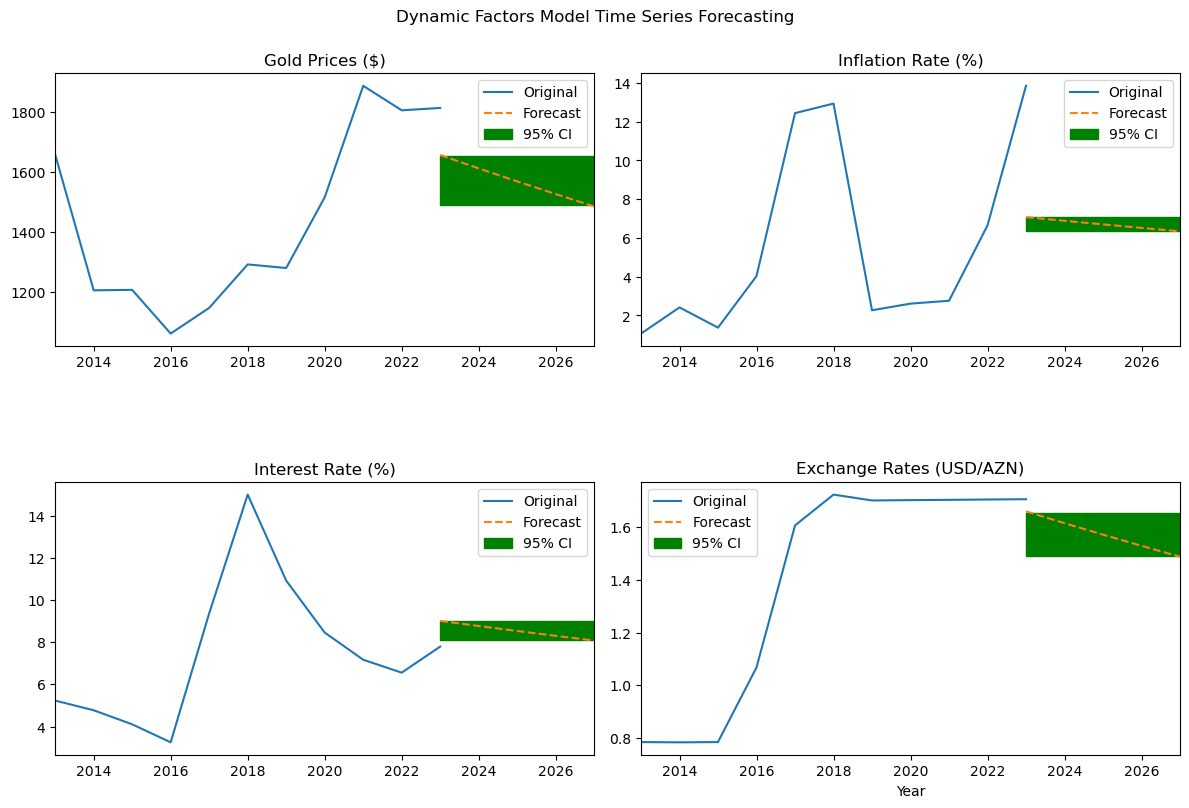

In [35]:
# Convert forecast to DataFrame
dfm_df = pd.DataFrame(DF_forecast.predicted_mean.values, index=pd.date_range(start=df_series.index[-1], periods=5, freq='Y'), columns=df_series.columns)
# Plotting
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
for i, col in enumerate(df_series.columns):
    ax = axes[i //2, i % 2]
    ax.plot(df_series.index, df_series[col], label='Original')
    ax.plot(dfm_df.index, dfm_df[col], label='Forecast', linestyle='--')
    ax.fill_between(dfm_df.index,dfm_df[col].quantile(0.025),dfm_df[col].quantile(0.975),color='green',label='95% CI')
    ax.set_title(col)
    ax.legend()
    ax.set_xlim(left=df_series.index[0],
               right=dfm_df.index[-1])
plt.tight_layout()
plt.suptitle("Dynamic Factors Model Time Series Forecasting")
plt.subplots_adjust(top=.9,hspace=.5)
plt.xlabel("Year")
plt.show()

In [36]:
dfm_df

,Gold Prices ($),Inflation Rate (%),Interest Rate (%),Exchange Rates (USD/AZN)
2022-12-31,1656.451004,7.077312,9.011134,1.659903
2023-12-31,1611.763536,6.886382,8.768033,1.615122
2024-12-31,1568.281638,6.700602,8.531491,1.571550
2025-12-31,1525.972788,6.519834,8.301329,1.529153
2026-12-31,1484.805340,6.343943,8.077377,1.487900


# Panel Data Analysis

## Fixed Effects Regression

## Random Effects Regression

# Model Evaluations

## Ordinary Least Square (OLS)

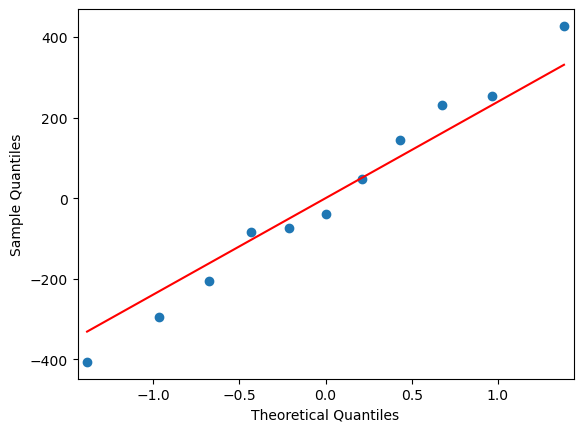

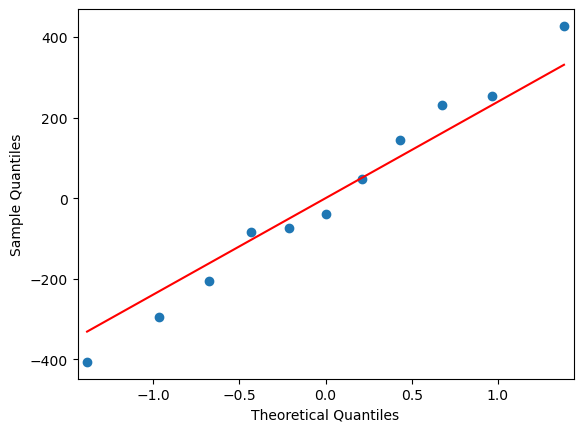

In [37]:
# Residual Analysis
ols_res = m1.resid
# Normality check
sm.qqplot(ols_res, line='s')

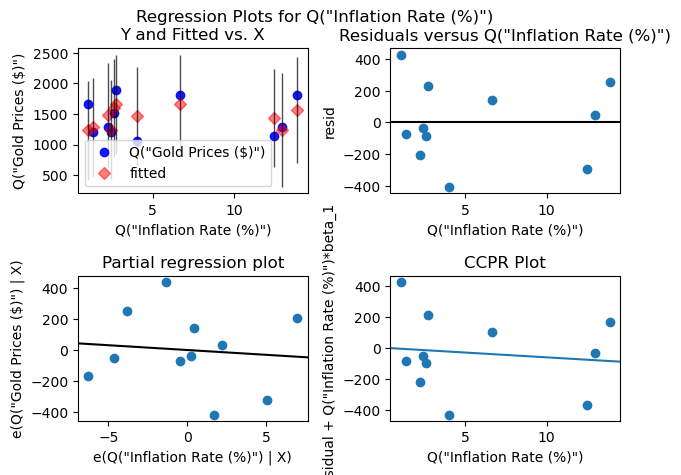

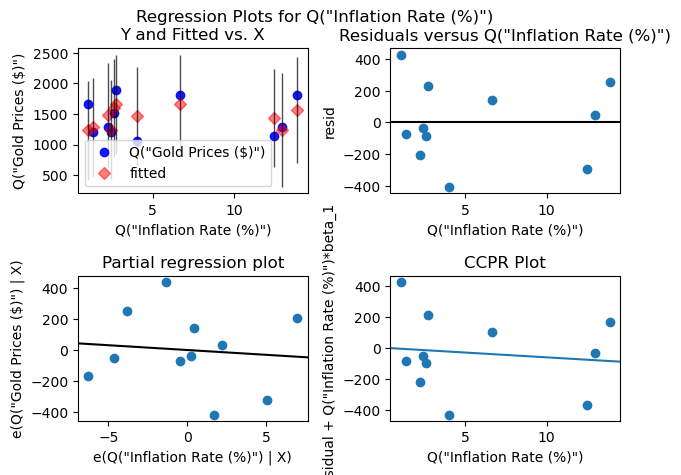

In [38]:
# Homoscedasticity check
sm.graphics.plot_regress_exog(m1,1)

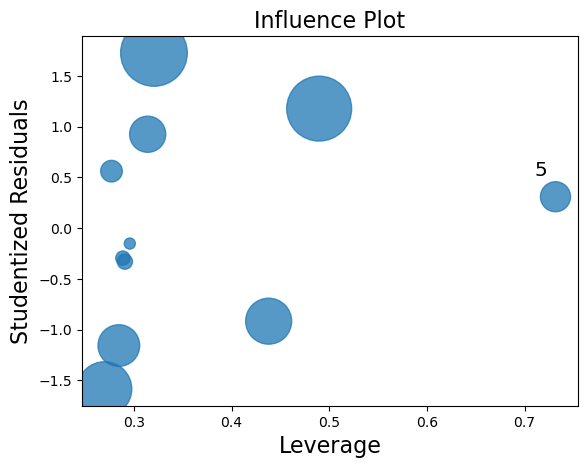

In [39]:
# Influence and Outlier Detection
ols_inf = m1.get_influence()
ols_inf_p = ols_inf.plot_influence()

In [40]:
# Normality check
normality_test = sm.stats.normal_ad(ols_res)
print("Normality Test p-value:", normality_test[1])
# Homoscedasticity check
homoscedasticity_test = sm.stats.diagnostic.het_goldfeldquandt(ols_res, m1.model.exog)
print("Homoscedasticity Test p-value:", homoscedasticity_test[1])
# Multicollinearity check (VIF)
X_ols = sm.add_constant(df.drop('Gold Prices ($)',axis=1))
vif_ols = pd.DataFrame()
vif_ols["variable"] = X_ols.columns
vif_ols["VIF"] = [variance_inflation_factor(X_ols.values, i) for i in range(X_ols.shape[1])]
print("VIF:")
print(vif_ols)
# Independence check (Durbin-Watson test)
durbin_watson_statistic = sm.stats.stattools.durbin_watson(ols_res)
print("Durbin-Watson Test statistic:", durbin_watson_statistic)

Normality Test p-value: 0.9720747026466506
Homoscedasticity Test p-value: 0.4440087569384843
VIF:
                   variable        VIF
0                     const  13.055677
1        Inflation Rate (%)   1.567458
2         Interest Rate (%)   2.224227
3  Exchange Rates (USD/AZN)   2.158273
Durbin-Watson Test statistic: 1.0396592883199967


## Robust Linear Model (RLM)

In [41]:
# Normality check
rlm_res = m2.resid
# Normality check
normality_test = sm.stats.normal_ad(rlm_res)
print("Normality Test p-value:", normality_test[1])
# Homoscedasticity check
homoscedasticity_test = sm.stats.diagnostic.het_goldfeldquandt(rlm_res, m2.model.exog)
print("Homoscedasticity Test p-value:", homoscedasticity_test[1])
# Multicollinearity check (VIF)
X_rlm = sm.add_constant(df.drop('Gold Prices ($)',axis=1))
vif_rlm = pd.DataFrame()
vif_rlm["variable"] = X_rlm.columns
vif_rlm["VIF"] = [variance_inflation_factor(X_rlm.values, i) for i in range(X_rlm.shape[1])]
print("VIF:")
print(vif_rlm)
# Independence check (Durbin-Watson test)
durbin_watson_statistic = sm.stats.stattools.durbin_watson(rlm_res)
print("Durbin-Watson Test statistic:", durbin_watson_statistic)

Normality Test p-value: 0.9805352612065327
Homoscedasticity Test p-value: 0.44400875693848313
VIF:
                   variable        VIF
0                     const  13.055677
1        Inflation Rate (%)   1.567458
2         Interest Rate (%)   2.224227
3  Exchange Rates (USD/AZN)   2.158273
Durbin-Watson Test statistic: 1.044749645553039


## Generalized Linear Model (GLM)

In [42]:
# Normality check
glm_res = m3.resid_pearson
# Normality check
normality_test = sm.stats.normal_ad(glm_res)
print("Normality Test p-value:", normality_test[1])
# Homoscedasticity check
homoscedasticity_test = sm.stats.diagnostic.het_goldfeldquandt(glm_res, m3.model.exog)
print("Homoscedasticity Test p-value:", homoscedasticity_test[1])
# Multicollinearity check (VIF)
X_glm = sm.add_constant(df.drop('Gold Prices ($)',axis=1))
vif_glm = pd.DataFrame()
vif_glm["variable"] = X_glm.columns
vif_glm["VIF"] = [variance_inflation_factor(X_glm.values, i) for i in range(X_glm.shape[1])]
print("VIF:")
print(vif_glm)
# Independence check (Durbin-Watson test)
durbin_watson_statistic = sm.stats.stattools.durbin_watson(glm_res)
print("Durbin-Watson Test statistic:", durbin_watson_statistic)

Normality Test p-value: 0.9720747026466506
Homoscedasticity Test p-value: 0.4440087569384843
VIF:
                   variable        VIF
0                     const  13.055677
1        Inflation Rate (%)   1.567458
2         Interest Rate (%)   2.224227
3  Exchange Rates (USD/AZN)   2.158273
Durbin-Watson Test statistic: 1.0396592883199967


## General Estimation Equations (GEE)

In [43]:
# Normality check
gee_res = m4.resid
# Normality check
normality_test = sm.stats.normal_ad(gee_res)
print("Normality Test p-value:", normality_test[1])
# Homoscedasticity check
homoscedasticity_test = sm.stats.diagnostic.het_goldfeldquandt(gee_res, m4.model.exog)
print("Homoscedasticity Test p-value:", homoscedasticity_test[1])
# Multicollinearity check (VIF)
X_gee = sm.add_constant(df.drop('Gold Prices ($)',axis=1))
vif_gee = pd.DataFrame()
vif_gee["variable"] = X_gee.columns
vif_gee["VIF"] = [variance_inflation_factor(X_gee.values, i) for i in range(X_gee.shape[1])]
print("VIF:")
print(vif_gee)
# Independence check (Durbin-Watson test)
durbin_watson_statistic = sm.stats.stattools.durbin_watson(gee_res)
print("Durbin-Watson Test statistic:", durbin_watson_statistic)

Normality Test p-value: 0.9720747026466506
Homoscedasticity Test p-value: 0.4440087569384913
VIF:
                   variable        VIF
0                     const  13.055677
1        Inflation Rate (%)   1.567458
2         Interest Rate (%)   2.224227
3  Exchange Rates (USD/AZN)   2.158273
Durbin-Watson Test statistic: 1.0396592883199955


## Mixed Effects Models (MixedLM)

In [44]:
# Normality check
mem_res = m5.resid
# Normality check
normality_test = sm.stats.normal_ad(mem_res)
print("Normality Test p-value:", normality_test[1])
# Homoscedasticity check
homoscedasticity_test = sm.stats.diagnostic.het_goldfeldquandt(mem_res, m5.model.exog)
print("Homoscedasticity Test p-value:", homoscedasticity_test[1])
# Multicollinearity check (VIF)
X_mem = sm.add_constant(df.drop('Gold Prices ($)',axis=1))
vif_mem = pd.DataFrame()
vif_mem["variable"] = X_mem.columns
vif_mem["VIF"] = [variance_inflation_factor(X_mem.values, i) for i in range(X_mem.shape[1])]
print("VIF:")
print(vif_mem)
# Independence check (Durbin-Watson test)
durbin_watson_statistic = sm.stats.stattools.durbin_watson(mem_res)
print("Durbin-Watson Test statistic:", durbin_watson_statistic)

Normality Test p-value: 0.9720747026466506
Homoscedasticity Test p-value: 0.44400875693849184
VIF:
                   variable        VIF
0                     const  13.055677
1        Inflation Rate (%)   1.567458
2         Interest Rate (%)   2.224227
3  Exchange Rates (USD/AZN)   2.158273
Durbin-Watson Test statistic: 1.0396592883199938
